# Pizza Place Sales Analysis by GIDEON NED

**Data source:** `Pizza Place Sales.zip` — four CSVs (`orders`, `order_details`, `pizzas`, `pizza_types`) plus a data dictionary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

## 1. Load the data

All four CSVs live in the `data/` folder. `pizza_types.csv` contains a couple of non-UTF-8 characters in the ingredients text, so it's read with `latin-1` encoding.

In [2]:
orders = pd.read_csv('data/orders.csv')
order_details = pd.read_csv('data/order_details.csv')
pizzas = pd.read_csv('data/pizzas.csv')
pizza_types = pd.read_csv('data/pizza_types.csv', encoding='latin-1')

for name, df in [('orders', orders), ('order_details', order_details),
                  ('pizzas', pizzas), ('pizza_types', pizza_types)]:
    print(f"{name}: {df.shape}")

orders: (21350, 3)
order_details: (48620, 4)
pizzas: (96, 4)
pizza_types: (32, 4)


In [3]:
data_dictionary = pd.read_csv('data/data_dictionary.csv')
data_dictionary

,Table,Field,Description
0,orders,order_id,Unique identifier for each order placed by a t...
1,orders,date,Date the order was placed (entered into the sy...
2,orders,time,Time the order was placed (entered into the sy...
3,order_details,order_details_id,Unique identifier for each pizza placed within...
4,order_details,order_id,Foreign key that ties the details in each orde...
5,order_details,pizza_id,Foreign key that ties the pizza ordered to its...
6,order_details,quantity,Quantity ordered for each pizza of the same ty...
7,pizzas,pizza_id,Unique identifier for each pizza (constituted ...
8,pizzas,pizza_type_id,Foreign key that ties each pizza to its broade...
9,pizzas,size,"Size of the pizza (Small, Medium, Large, X Lar..."


### Quick look at each table

In [4]:
display(orders.head())
display(order_details.head())
display(pizzas.head())
display(pizza_types.head())

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


### Data quality check

Before joining, check for nulls and duplicates across the tables.

In [5]:
for name, df in [('orders', orders), ('order_details', order_details),
                  ('pizzas', pizzas), ('pizza_types', pizza_types)]:
    print(f"--- {name} ---")
    print("Nulls:\n", df.isnull().sum())
    print("Duplicate rows:", df.duplicated().sum())
    print()

--- orders ---
Nulls:
 order_id    0
date        0
time        0
dtype: int64
Duplicate rows: 0

--- order_details ---
Nulls:
 order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64
Duplicate rows: 0

--- pizzas ---
Nulls:
 pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64
Duplicate rows: 0

--- pizza_types ---
Nulls:
 pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64
Duplicate rows: 0



No missing values and no duplicate rows in any table — the dataset is clean.

## 2. Join into a single DataFrame

`order_details` → `orders` (on `order_id`) → `pizzas` (on `pizza_id`) → `pizza_types` (on `pizza_type_id`). We also engineer a few time-based columns (`revenue`, weekday, month, hour) that will be reused throughout the analysis.

In [6]:
df = (order_details
      .merge(orders, on='order_id', how='left')
      .merge(pizzas, on='pizza_id', how='left')
      .merge(pizza_types, on='pizza_type_id', how='left'))

# Feature engineering
df['date'] = pd.to_datetime(df['date'])
df['revenue'] = df['quantity'] * df['price']
df['weekday'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['month_num'] = df['date'].dt.month
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

print(df.shape)
df.head()

(48620, 17)


,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,weekday,month,month_num,hour
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,Thursday,January,1,11
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,Thursday,January,1,11
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,Thursday,January,1,11
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,Thursday,January,1,11
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,Thursday,January,1,11


## 3. Total revenue / sales

In [7]:
total_revenue = df['revenue'].sum()
print(f"Total revenue: ${total_revenue:,.2f}")

Total revenue: $817,860.05


**Insight:** The pizza place generated roughly **$817,860** in revenue over the year (2015) — this is our baseline for everything else.

## 4. Total quantity sold

In [8]:
total_quantity = df['quantity'].sum()
print(f"Total pizzas sold: {total_quantity:,}")

Total pizzas sold: 49,574


**Insight:** Just under 50,000 individual pizzas were sold across the year, at an average of roughly 137 pizzas/day.

## 5. Total orders

In [9]:
total_orders = df['order_id'].nunique()
print(f"Total orders: {total_orders:,}")
print(f"Average pizzas per order: {total_quantity/total_orders:.2f}")
print(f"Average revenue per order: ${total_revenue/total_orders:.2f}")

Total orders: 21,350
Average pizzas per order: 2.32
Average revenue per order: $38.31


**Insight:** There were about 21,350 distinct orders, averaging **~2.3 pizzas** and **~$38** in revenue per order — most orders are for a couple of pizzas rather than a single one.

## 6. How many pizza types do they sell?

In [10]:
n_pizza_types = df['pizza_type_id'].nunique()
n_size_variants = df['pizza_id'].nunique()
n_categories = df['category'].nunique()
print(f"Distinct pizza types (recipes): {n_pizza_types}")
print(f"Distinct pizza SKUs (type + size): {n_size_variants}")
print(f"Categories: {sorted(df['category'].unique())} ({n_categories} total)")

Distinct pizza types (recipes): 32
Distinct pizza SKUs (type + size): 91
Categories: ['Chicken', 'Classic', 'Supreme', 'Veggie'] (4 total)


**Insight:** The menu has **32 distinct pizza recipes**, sold across up to 4 sizes each (91 SKUs total), spanning 4 categories: Chicken, Classic, Supreme, and Veggie.

## 7. Average price of the pizzas

In [11]:
avg_price_menu = pizzas['price'].mean()
avg_price_sold = df['price'].mean()
print(f"Average listed menu price (all SKUs): ${avg_price_menu:.2f}")
print(f"Average price of pizzas actually sold: ${avg_price_sold:.2f}")

pizzas.groupby('size')['price'].mean().sort_values()

Average listed menu price (all SKUs): $16.44
Average price of pizzas actually sold: $16.49


size
S      12.512500
M      15.991935
L      20.022581
XL     25.500000
XXL    35.950000
Name: price, dtype: float64

**Insight:** The average listed price across all SKUs is about **$16.40**, close to what customers actually paid on average (~$16.44) — pricing by size scales roughly as expected (S < M < L < XL/XXL).

## 8. Peak hours of sales

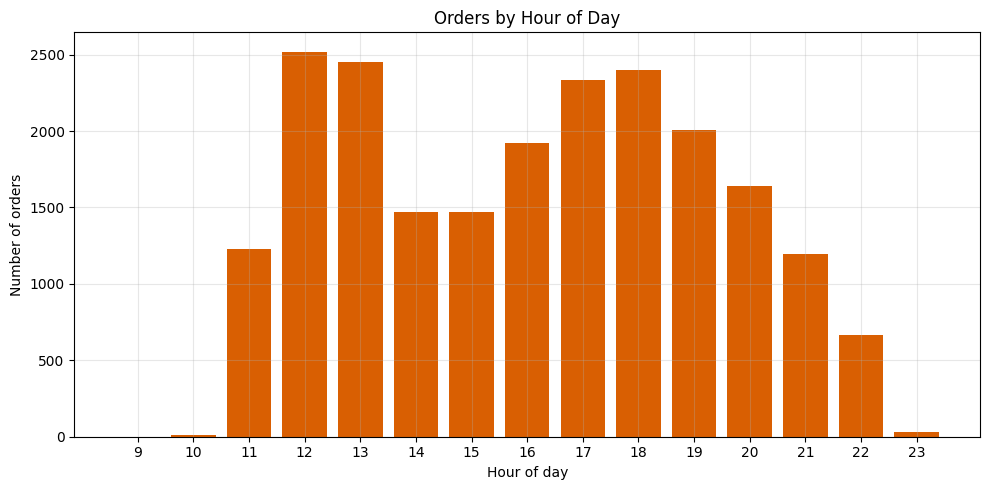

,hour,orders,revenue,quantity
3,12,2520,111877.90,6776
4,13,2455,106065.70,6413
9,18,2399,89296.85,5417
8,17,2336,86237.45,5211
10,19,2009,72628.90,4406


In [12]:
hourly = df.groupby('hour').agg(orders=('order_id', 'nunique'),
                                  revenue=('revenue', 'sum'),
                                  quantity=('quantity', 'sum')).reset_index()

fig, ax = plt.subplots()
ax.bar(hourly['hour'], hourly['orders'], color='#d95f02')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of orders')
ax.set_title('Orders by Hour of Day')
ax.set_xticks(range(9, 24))
plt.tight_layout()
plt.show()

hourly.sort_values('orders', ascending=False).head(5)

**Insight:** Sales cluster around two peaks — **lunch (12:00–13:00)** and **dinner (17:00–19:00)** — with 12:00–13:00 being the single busiest hour. Sales taper off sharply after 9pm and are minimal before 10am, consistent with typical restaurant meal-time traffic.

## 9. Total sales by day of week

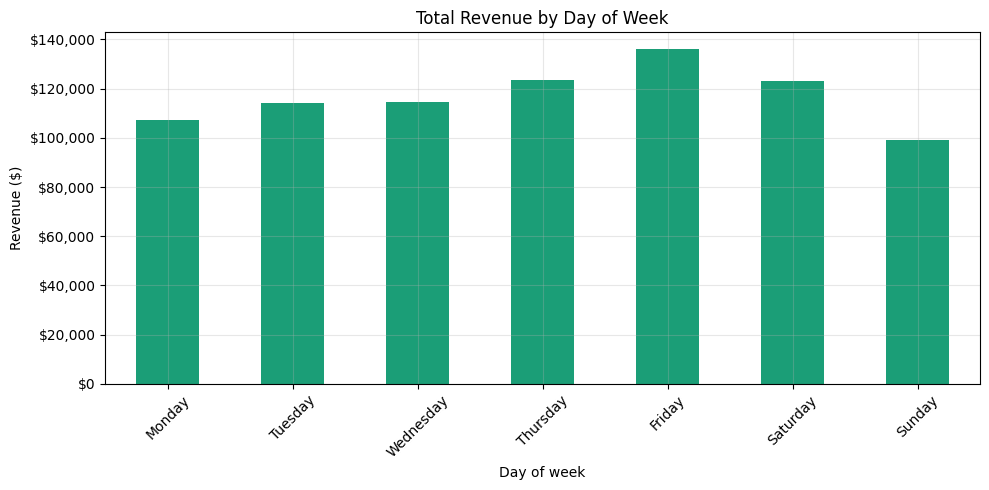

weekday
Friday       136073.90
Thursday     123528.50
Saturday     123182.40
Wednesday    114408.40
Tuesday      114133.80
Monday       107329.55
Sunday        99203.50
Name: revenue, dtype: float64

In [13]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = df.groupby('weekday')['revenue'].sum().reindex(weekday_order)

fig, ax = plt.subplots()
weekday_sales.plot(kind='bar', ax=ax, color='#1b9e77')
ax.set_xlabel('Day of week')
ax.set_ylabel('Revenue ($)')
ax.set_title('Total Revenue by Day of Week')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

weekday_sales.sort_values(ascending=False)

**Insight:** **Friday** brings in the most revenue, followed closely by Thursday and Saturday — the back half of the week. **Sunday** is the slowest day. The gap between the best and worst day is real but not huge (roughly 15–20%), so demand is fairly steady with a weekend-leaning lift.

## 10. Top 5 bestselling pizzas

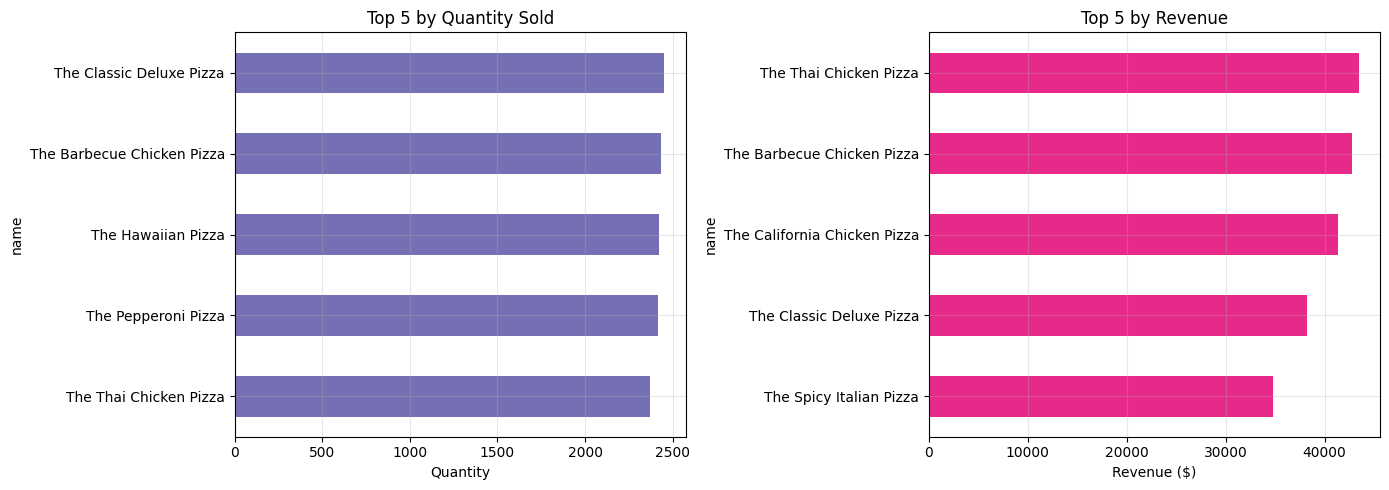

By quantity:
name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

By revenue:
name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
Name: revenue, dtype: float64


In [14]:
top5_by_qty = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)
top5_by_rev = df.groupby('name')['revenue'].sum().sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top5_by_qty.sort_values().plot(kind='barh', ax=axes[0], color='#7570b3')
axes[0].set_title('Top 5 by Quantity Sold')
axes[0].set_xlabel('Quantity')

top5_by_rev.sort_values().plot(kind='barh', ax=axes[1], color='#e7298a')
axes[1].set_title('Top 5 by Revenue')
axes[1].set_xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

print("By quantity:")
print(top5_by_qty)
print("\nBy revenue:")
print(top5_by_rev)

**Insight:** The **Classic Deluxe, Barbecue Chicken, Hawaiian, Pepperoni, and Thai Chicken** pizzas dominate by quantity sold. The revenue leaderboard is similar but the **Thai Chicken and California Chicken** pizzas punch above their sales volume in revenue terms — they're priced higher, so fewer units sold still generates strong revenue. Chicken-category pizzas are clearly a strong performer.

## 11. Monthly sales trend

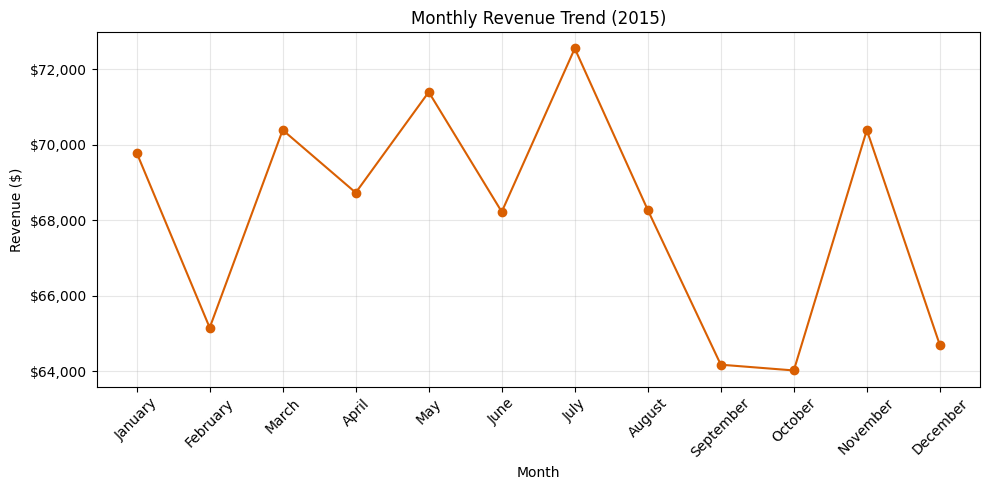

,month,revenue
0,January,69793.30
1,February,65159.60
2,March,70397.10
3,April,68736.80
4,May,71402.75
5,June,68230.20
6,July,72557.90
7,August,68278.25
8,September,64180.05
9,October,64027.60


In [15]:
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
monthly = df.groupby(['month_num','month'])['revenue'].sum().reset_index().sort_values('month_num')

fig, ax = plt.subplots()
ax.plot(monthly['month'], monthly['revenue'], marker='o', color='#d95f02')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.set_title('Monthly Revenue Trend (2015)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly[['month','revenue']]

**Insight:** Revenue is fairly stable month-to-month (~$64k–$72k), with **July and November/January** standing out as the strongest months and **October** as the weakest. There's no strong seasonal growth trend across the year — this reads more like consistent, mature demand than a growing business, with minor month-to-month noise rather than a clear seasonal pattern.

## 12. Underperforming pizza types

Looking at both total quantity sold and how many *distinct orders* each pizza type appears in, to flag items that are rarely chosen.

In [16]:
type_perf = df.groupby('name').agg(
    quantity_sold=('quantity','sum'),
    revenue=('revenue','sum'),
    orders_appeared_in=('order_id','nunique'),
    category=('category','first')
).sort_values('quantity_sold')

print("Bottom 5 pizzas by quantity sold:")
display(type_perf.head(5))

print("Bottom 5 pizzas by revenue:")
display(type_perf.sort_values('revenue').head(5))

Bottom 5 pizzas by quantity sold:


,quantity_sold,revenue,orders_appeared_in,category
name,,,,
The Brie Carre Pizza,490,11588.50,480,Supreme
The Mediterranean Pizza,934,15360.50,912,Veggie
The Calabrese Pizza,937,15934.25,918,Supreme
The Spinach Supreme Pizza,950,15277.75,918,Supreme
The Soppressata Pizza,961,16425.75,941,Supreme


Bottom 5 pizzas by revenue:


,quantity_sold,revenue,orders_appeared_in,category
name,,,,
The Brie Carre Pizza,490,11588.50,480,Supreme
The Green Garden Pizza,997,13955.75,976,Veggie
The Spinach Supreme Pizza,950,15277.75,918,Supreme
The Mediterranean Pizza,934,15360.50,912,Veggie
The Spinach Pesto Pizza,970,15596.00,945,Veggie


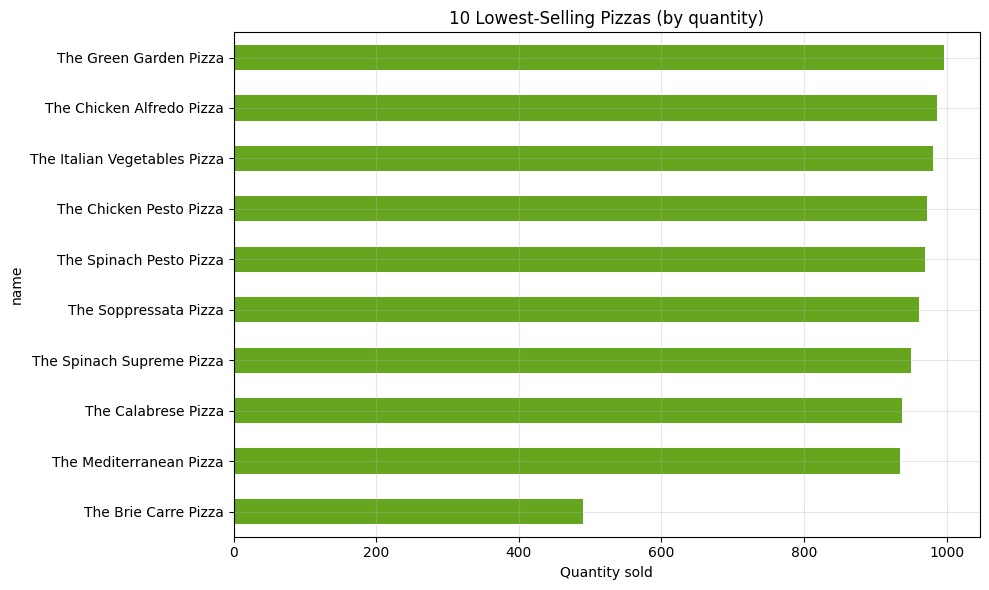

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
type_perf.sort_values('quantity_sold').head(10)['quantity_sold'].plot(kind='barh', ax=ax, color='#66a61e')
ax.set_title('10 Lowest-Selling Pizzas (by quantity)')
ax.set_xlabel('Quantity sold')
plt.tight_layout()
plt.show()

**Insight:** The **Brie Carre, Mediterranean, Calabrese, Spinach Supreme, and Soppressata** pizzas sell the least, both in quantity and revenue. The Brie Carre in particular sells roughly half as many units as the top pizza — these are candidates for menu review (reprice, promote, or replace) since they tie up menu space and prep variety for relatively little return.

## 13. Sales by category

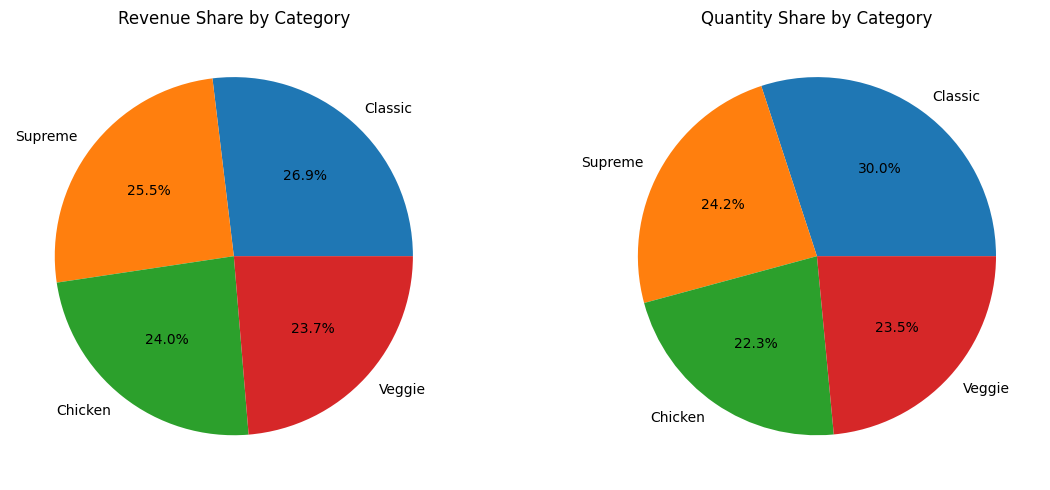

,quantity_sold,revenue,num_types
category,,,
Classic,14888,220053.10,8
Supreme,11987,208197.00,9
Chicken,11050,195919.50,6
Veggie,11649,193690.45,9


In [18]:
category_perf = df.groupby('category').agg(
    quantity_sold=('quantity','sum'),
    revenue=('revenue','sum'),
    num_types=('pizza_type_id','nunique')
).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
category_perf['revenue'].plot(kind='pie', ax=axes[0], autopct='%1.1f%%', ylabel='')
axes[0].set_title('Revenue Share by Category')
category_perf['quantity_sold'].plot(kind='pie', ax=axes[1], autopct='%1.1f%%', ylabel='')
axes[1].set_title('Quantity Share by Category')
plt.tight_layout()
plt.show()

category_perf

**Insight:** **Classic** and **Supreme** categories lead in both quantity and revenue, together accounting for over half of sales. **Veggie** pizzas sell the least, despite having a similar number of menu items as the other categories — suggesting weaker demand for that category overall rather than just a few weak individual pizzas.

## 14. Sales by pizza size

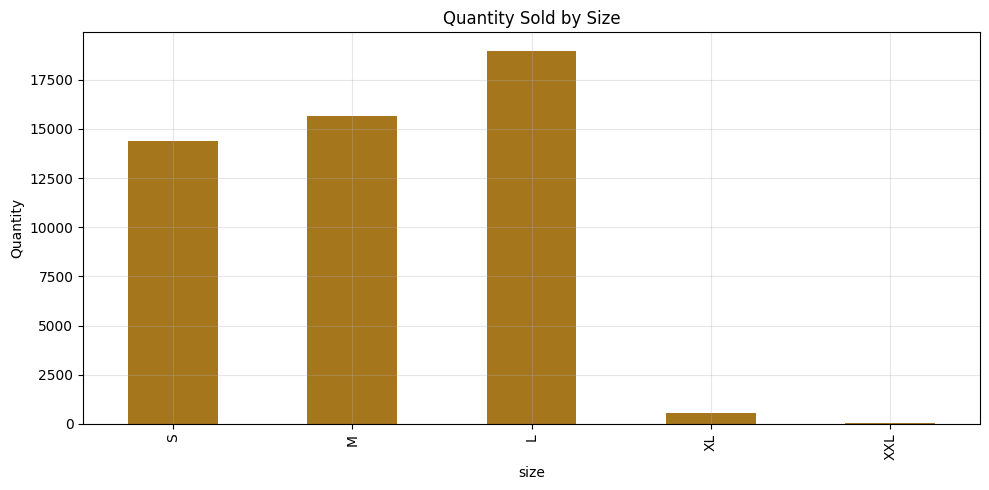

,quantity_sold,revenue
size,,
S,14403,178076.50
M,15635,249382.25
L,18956,375318.70
XL,552,14076.00
XXL,28,1006.60


In [19]:
size_perf = df.groupby('size').agg(
    quantity_sold=('quantity','sum'),
    revenue=('revenue','sum')
).reindex(['S','M','L','XL','XXL']).dropna()

fig, ax = plt.subplots()
size_perf['quantity_sold'].plot(kind='bar', ax=ax, color='#a6761d')
ax.set_title('Quantity Sold by Size')
ax.set_ylabel('Quantity')
plt.tight_layout()
plt.show()

size_perf

**Insight:** **Large (L)** is the most popular size by a wide margin, followed by Medium and Small. XL and XXL are niche sizes (only offered on a few specialty pizzas) and sell in very small volumes — likely limited-availability options rather than core menu items.

## Summary of key findings

- **Total revenue:** $817,860 across 21,350 orders and ~49,570 pizzas sold
  
- **Menu:** 32 pizza recipes across 4 categories (Chicken, Classic, Supreme, Veggie), sold in up to 5 sizes; average price ~$16.40.
- **Peak hours:** Lunch (12–1pm) and dinner (5–7pm) are the busiest windows — a classic two-peak restaurant pattern.
- **Best day:** Friday, with Thursday and Saturday close behind; Sunday is the slowest.
- **Best sellers:** Classic Deluxe, Barbecue Chicken, Hawaiian, Pepperoni, and Thai Chicken lead in volume; Thai Chicken and California Chicken over-index on revenue due to higher price points.
- **Seasonality:** Revenue is fairly flat across the year (no strong growth or seasonal spike), with July and January/November as slightly stronger months and October as the weakest.
- **Underperformers:** Brie Carre, Mediterranean, Calabrese, Spinach Supreme, and Soppressata are the weakest sellers — good candidates for menu review.
- **Category mix:** Classic and Supreme drive the majority of sales; Veggie underperforms as a category, not just individual items.
- **Size mix:** Large is the dominant size; XL/XXL are niche.

### Possible next steps for the business
- Consider trimming or reworking the bottom 3–5 pizzas to simplify prep and menu real estate.
- Investigate why Veggie pizzas underperform (pricing, recipe appeal, marketing) rather than assuming it's item-specific.
- Staff up appropriately for the lunch and dinner peaks, and consider Sunday promotions to lift the slowest day.
- Since revenue is flat year-round, seasonal promotions or limited-time items could be tested to drive incremental growth rather than relying on organic seasonal upticks.